# Velocity Analysis Walkthrough

The analysis applied to velocity datasets used in the project, originating from the Stitch in Time dataset.

In [1]:
import os
import warnings
from contextlib import redirect_stdout
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import matplotlib.text as mtext
import numpy as np
import utide as ut
import xarray as xr
from matplotlib.legend import Legend
from matplotlib.lines import Line2D
from matplotlib.offsetbox import DrawingArea
from matplotlib.patches import Arc
from numpy import floating
from numpy.typing import NDArray
from scipy import signal as sig
from tqdm import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning, message="Mean of empty slice")

## Loading and initial visualization

In [2]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
VEL_PATH = DATA_DIR / "NH10_Mooring_Data/nh10_hourly_data_1997_2024_v5.nc"

In [3]:
# start by loading and examining the velocity dataset
velocity = xr.open_dataset(VEL_PATH)
# convert depth to float to allow typical numerical operations
velocity["depth"] = velocity["depth"].astype(float)
# examine velocity
velocity

<xarray.Dataset> Size: 156MB
Dimensions:  (depth: 41, time: 234255)
Coordinates:
  * time     (time) datetime64[ns] 2MB 1997-08-12T12:00:00 ... 2024-05-03T02:...
  * depth    (depth) float64 328B 0.0 2.0 4.0 6.0 8.0 ... 74.0 76.0 78.0 80.0
Data variables:
    u        (depth, time) float64 77MB ...
    v        (depth, time) float64 77MB ...

In [4]:
def plot_velocity(
    velocity: xr.DataArray,
    vmin: float = -0.5,
    vmax: float = 0.5,
) -> None:
    """Plot the velocity profiles for each deployment period.

    Args:
        velocity (xr.DataArray): A dataarray containing a velocity componenet,
            with 'time' and 'depth' dimensions.
        vmin (float): Minimum value to plot in the colorbar.
        vmax (float): Maximum value to plot in the colorbar.

    """
    _, ax = plt.subplots(figsize=(12, 6))

    cmap = plt.get_cmap("RdBu_r")
    cmap.set_bad("gray", 1.0)

    pcm = ax.pcolormesh(
        velocity["time"],
        -velocity["depth"],
        velocity,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar(pcm, ax=ax, label="Eastward Velocity (m/s)", extend="both")

    ax.axhline(-10, color="k", linestyle="--")
    ax.axhline(-70, color="k", linestyle="--")

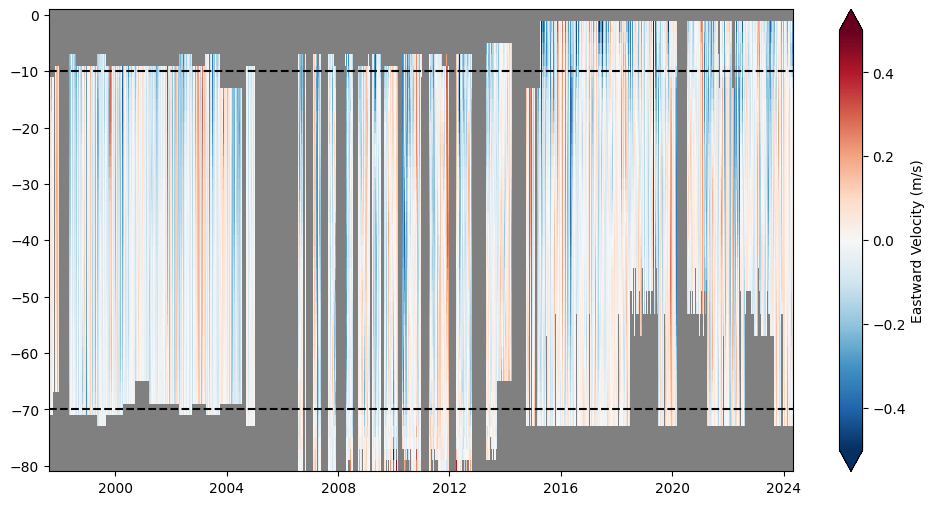

In [5]:
# let's start by taking a look at the velocity before any processing steps are applied
plot_velocity(velocity["u"])

These initial cross-shelf velocities certainly seem reasonable. There's blanking near the top and bottom, which makes sense. The horizontal dashed lines indicate depths of 15 m and 65 m, which will be important later (we are going to re-extrapolate over these depths).

## Initial tidal analysis

Now let's get a sense of the main tidal constituents, broken down for each deployment.

In [6]:
def fit_utide(u: xr.DataArray, v: xr.DataArray) -> dict:
    """Fit a T-Tide model to the given u and v components.

    Returns:
        dict: A dictionary containing the tidal constituents and their parameters.

    """
    # don't need to print the output of utide, so redirect stdout to devnull
    with (
        Path(os.devnull).open("w", encoding="utf-8") as devnull,
        redirect_stdout(devnull),
    ):
        # just save the dict output of utide
        coef = ut.solve(
            u["time"],
            u,
            v,
            lat=44.64,
            method="ols",
            conf_int="linear",
        )

    return coef


def fit_utide_from_ds(
    ds: xr.Dataset,
) -> xr.Dataset:
    """Fit tidal constituents from a dataset containing u and v components.

    Args:
        ds (xr.Dataset): A dataset containing the u and v components of velocity,
            with a 'depth' dimension.

    Returns:
        xr.Dataset: A dataset containing the fitted tidal constituents and their parameters.

    """
    ds_list: list[xr.Dataset] = []
    for depth in tqdm(ds["depth"], desc="Fitting UTide"):
        # skip depths where either u or v is all NaN
        if np.all(np.isnan(ds["u"].sel(depth=depth))) or np.all(
            np.isnan(ds["v"].sel(depth=depth)),
        ):
            continue

        # run utide to fit the tidal constituents for a given depth
        out = fit_utide(
            ds["u"].sel(depth=depth),
            ds["v"].sel(depth=depth),
        )

        # convert the output to a dataset
        out["name"] = [name.strip() for name in out["name"]]
        out_ds = xr.Dataset(
            {
                "freq": (["constituent"], out["aux"]["frq"]),
                "snr": (["constituent"], out["diagn"]["SNR"]),
                "pe": (["constituent"], out["diagn"]["PE"]),
                "major": (["constituent"], out["Lsmaj"]),
                "major_ci": (["constituent"], out["Lsmaj_ci"]),
                "minor": (["constituent"], out["Lsmin"]),
                "minor_ci": (["constituent"], out["Lsmin_ci"]),
                "inclination": (["constituent"], out["theta"]),
                "inclination_ci": (["constituent"], out["theta_ci"]),
                "phase": (["constituent"], out["Lsmaj"]),
                "phase_ci": (["constituent"], out["Lsmaj_ci"]),
            },
            coords={
                "time": ds.time,
                "constituent": out["name"],
            },
        )
        out_ds["u_mean"] = ([], out["umean"])
        out_ds["v_mean"] = ([], out["vmean"])
        out_ds["u_slope"] = ([], out["uslope"])
        out_ds["v_slope"] = ([], out["vslope"])
        out_ds = out_ds.expand_dims({"depth": [depth.values.astype(int)]}, axis=0)
        ds_list.append(out_ds)

    # combine the list of datasets along the depth dimension
    tide_out = xr.concat(ds_list, dim="depth")
    tide_out.attrs = {
        "description": "tidal constituents from UTide https://www.po.gso.uri.edu/~codiga/utide/utide.htm",
    }

    return tide_out

In [7]:
# split up by deployment times
GLOBEC_TIME = slice(np.datetime64("1997-01-01"), np.datetime64("2004-12-31"))  # we don't end up using this one
NANOOS_TIME = slice(np.datetime64("2006-07-01"), np.datetime64("2014-09-30"))
OOI_TIME = slice(np.datetime64("2015-04-01"), None)

# select velocity data for deployment periods
velocity_nanoos = velocity.sel(time=NANOOS_TIME)
velocity_ooi = velocity.sel(time=OOI_TIME)

# fit utide to each deployment period
tide_nanoos = fit_utide_from_ds(velocity_nanoos)
tide_ooi = fit_utide_from_ds(velocity_ooi)

Fitting UTide: 100%|██████████| 41/41 [01:57<00:00,  2.87s/it]


We omit the GLOBEC deployments from tidal analysis, since these data have been provided as a daily mean, preventing the fitting of tidal constituents.



In [8]:
# just a convenience functions for plotting the tidal constituents
def plot_tidal_constituents(
    tide_ds: xr.Dataset,
    fig: plt.Figure,
    constituents: list[str],
    colors: list[str],
    linestyle: str = "-",
) -> plt.Figure:
    """Plot the tidal constituents from a T-Tide output dataset.

    Args:
        tide_ds (xr.Dataset): A dataset containing the tidal constituents and their parameters
            produced by `fit_utide_from_ds`.
        fig (Figure): A matplotlib figure to plot on.
        constituents (list[str]): The name of the tidal constituents to plot.
        colors (list[str]): A list of colors to use for each constituent.
        linestyle (str, optional): The line style to use for the plots. Defaults to "-".

    Returns:
        plt.Figure: The input figure with the tidal constituents plotted.

    Raises:
        ValueError: If the length of the color list does not match the length of the constituents list.

    """
    if len(colors) != len(constituents):
        msg = f"Length of colors list ({len(colors)}) must match length of constituents list ({len(constituents)})."
        raise ValueError(msg)

    axs = fig.axes

    for const, color in zip(constituents, colors, strict=True):
        tide_ds_const = tide_ds.sel(constituent=const)
        axs[0].plot(tide_ds_const["major"], -tide_ds_const["depth"], label=const, color=color, linestyle=linestyle)
        axs[0].fill_betweenx(
            -tide_ds_const["depth"],
            tide_ds_const["major"] - tide_ds_const["major_ci"],
            tide_ds_const["major"] + tide_ds_const["major_ci"],
            alpha=0.3,
            color=color,
        )

        axs[1].plot(tide_ds_const["minor"], -tide_ds_const["depth"], label=const, color=color, linestyle=linestyle)
        axs[1].fill_betweenx(
            -tide_ds_const["depth"],
            tide_ds_const["minor"] - tide_ds_const["minor_ci"],
            tide_ds_const["minor"] + tide_ds_const["minor_ci"],
            alpha=0.3,
            color=color,
        )

        axs[2].plot(
            tide_ds_const["inclination"],
            -tide_ds_const["depth"],
            label=const,
            color=color,
            linestyle=linestyle,
        )
        axs[2].fill_betweenx(
            -tide_ds_const["depth"],
            tide_ds_const["inclination"] - tide_ds_const["inclination_ci"],
            tide_ds_const["inclination"] + tide_ds_const["inclination_ci"],
            alpha=0.3,
            color=color,
        )

        axs[3].plot(tide_ds_const["phase"], -tide_ds_const["depth"], label=const, color=color, linestyle=linestyle)
        axs[3].fill_betweenx(
            -tide_ds_const["depth"],
            tide_ds_const["phase"] - tide_ds_const["phase_ci"],
            tide_ds_const["phase"] + tide_ds_const["phase_ci"],
            alpha=0.3,
            color=color,
        )

        axs[4].plot(tide_ds_const["snr"], -tide_ds_const["depth"], label=const, color=color, linestyle=linestyle)
        axs[4].set_xscale("log")
        axs[4].axvline(2, color="k", linestyle="--")

        axs[0].set_xlabel("Major Axis [$\\mathsf{cm \\; s^{-1}}$]")
        axs[1].set_xlabel("Minor Axis [$\\mathsf{cm \\; s^{-1}}$]")
        axs[2].set_xlabel("Inclination [degrees]")
        axs[3].set_xlabel("Phase [degrees]")
        axs[4].set_xlabel("Signal-to-Noise Ratio")

    return fig


class LegendTitle:
    """Used to create subtitles in MatPlotLib legends.

    For example:
        `plt.legend(handles, labels, handler_map={str: LegendTitle(text_props={"fontsize": 10}, width=55)})`
    """

    def __init__(self, text_props: dict | None = None, width: float | None = None) -> None:  # noqa: D107
        self.text_props = text_props or {}
        self.width = width or None
        super().__init__()

    def legend_artist(self, legend: Legend, orig_handle: str, fontsize: float, handlebox: DrawingArea) -> mtext.Text:  # noqa: ARG002, D102
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        title = mtext.Text(
            x0,
            y0,
            f"\\underline{{\\textbf{{{orig_handle}}}}}",
            usetex=True,
            **self.text_props,
        )
        handlebox.add_artist(title)
        if self.width is not None:
            handlebox.width = self.width
        return title

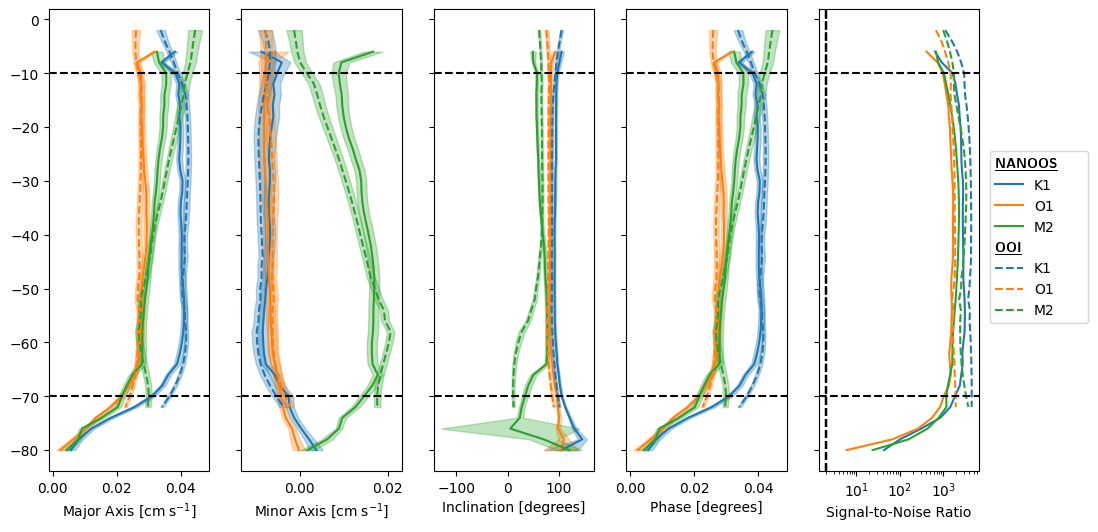

In [9]:
constituents = ["K1", "O1", "M2"]
colors = ["C0", "C1", "C2"]

fig, _ = plt.subplots(nrows=1, ncols=5, figsize=(12, 6), sharey=True)

# plot the tidal constituents for each deployment period on the same axes, using different line styles
fig = plot_tidal_constituents(tide_nanoos, fig, constituents, colors, linestyle="-")
fig = plot_tidal_constituents(tide_ooi, fig, constituents, colors, linestyle="--")

# fancy styling for the legend to add titles for each deployment period
axs = fig.axes
handles, labels = axs[0].get_legend_handles_labels()
# we add string type handles that will be converted to legend titles by the handler map in the legend call below
handles.insert(0, "NANOOS")  # ty:ignore[invalid-argument-type]
labels.insert(0, "")
handles.insert(4, "OOI")  # ty:ignore[invalid-argument-type]
labels.insert(4, "")
fig.legend(
    handles,
    labels,
    loc="center",
    bbox_to_anchor=(0.95, 0.5),
    handler_map={str: LegendTitle(text_props={"fontsize": 10}, width=55)},
)

# add some reference lines for the surface and bottom contamination
for ax in axs:
    ax.axhline(-10, color="k", linestyle="--")
    ax.axhline(-70, color="k", linestyle="--")

The "kinks" in the tidal constituents above ~10 m depth indicate that these depths are in some way contaminated. This is the motivation for applying a surface and bottom extrapolation to the velocity dataset.

## Extrapolating surface and bottom velocity

The next step is to actually do the extrapolation. At the surface, we will take a constant extrapolation, using the shallowest non-null value and propagating this up to the surface.

In [10]:
MIN_DEPTH = 10
MAX_DEPTH = 70

# make a copy so we don't modify the original dataset
velocity_extrap = velocity.copy()

# first start by extrapolating any remaining NaNs that might be in the middle of the velocity profile
# we eventually want to use extrapolate_na to extrapolate the surface and bottom depths
# so we want to make sure that there isn't any remaining NaNs in the middle of the profile
velocity_extrap = velocity_extrap.interpolate_na(dim="depth", method="polynomial", order=1)

# now mask out the surface and depths
velocity_extrap = velocity_extrap.where(velocity_extrap["depth"] >= MIN_DEPTH)

# bfill will backfill the surface values with the nearest valid value, only within 20 m (2 m depth bins)
velocity_extrap = velocity_extrap.bfill(dim="depth", limit=10)

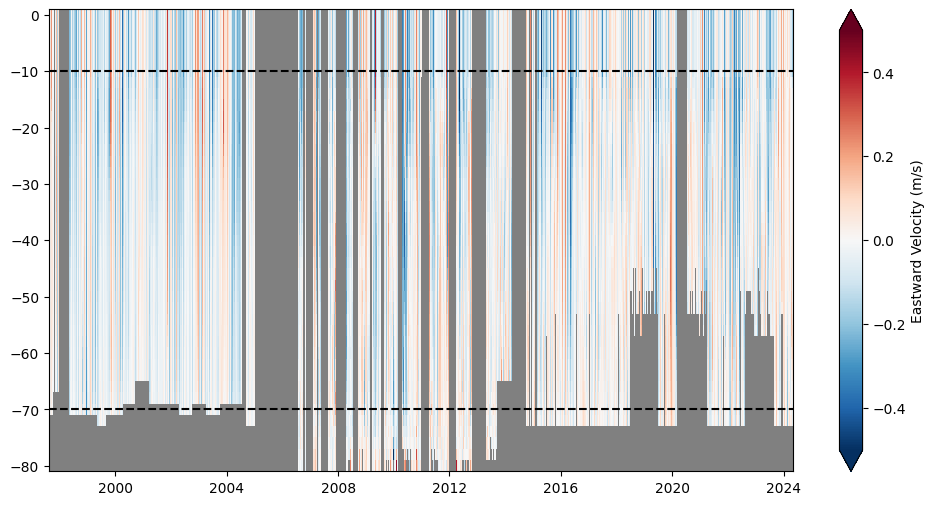

In [11]:
# now let's take another look at the velocity
plot_velocity(velocity_extrap["u"])

Great! Looks like that's working well. Now on to the trickier part, extrapolating the bottom to zero.

In [12]:
# velocity_extrap = velocity_extrap.where(velocity_extrap["depth"] <= MAX_DEPTH)

# we only want to set zeroes where there is data in the original
# i.e., selecting for times when there is at least one valid velocity measurement in the original profile
zeroes = xr.full_like(velocity_extrap.isel(depth=-1), 0)
zeroes = zeroes.where(~velocity.isnull().all(dim="depth"))
# we also don't want to extrapolate if there isn't any valid data near the MAX_DEPTH we set earlier
zeroes = zeroes.where(~velocity.isnull().sel(depth=MAX_DEPTH, method="nearest"))

# set the deepest value to zero
velocity_extrap[{"depth": -1}] = zeroes

# now use linear extrapolation over a max gap of 20 m (2 m depth bins) to fill any remaining NaNs
# at this point, only bottom values should be remaining NaN, so this will extrapolate only the bottom values
velocity_extrap = velocity_extrap.interpolate_na(dim="depth", method="polynomial", order=1, limit=10)

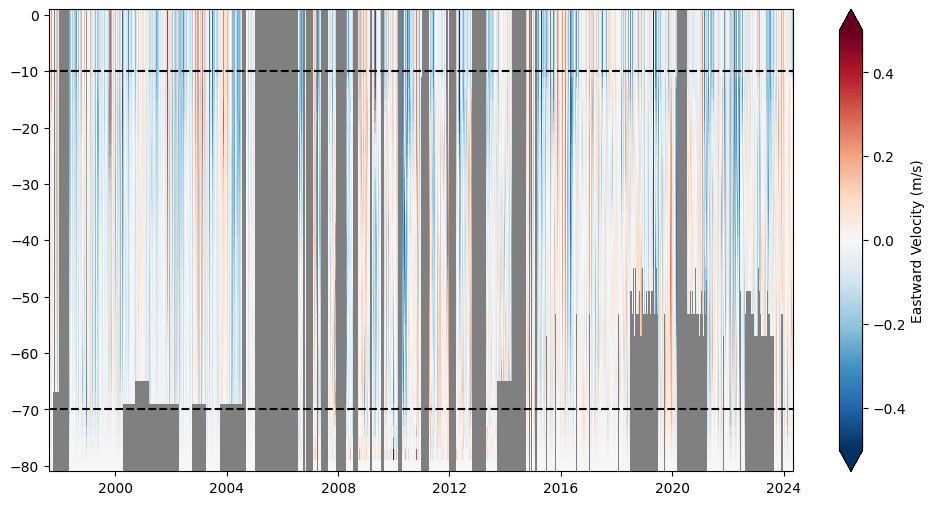

In [13]:
# now let's take another look at the velocity
plot_velocity(velocity_extrap["u"])

Excellent!

## Repeating tidal analysis

Post extrapolation, we're going to repeat the tidal analysis to make sure things are looking reasonable.

In [14]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered")
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="divide by zero encountered")

    # select velocity data for deployment periods
    velocity_extrap_nanoos = velocity_extrap.sel(time=NANOOS_TIME)
    velocity_extrap_ooi = velocity_extrap.sel(time=OOI_TIME)

    # fit utide to each deployment period
    tide_extrap_nanoos = fit_utide_from_ds(velocity_extrap_nanoos)
    tide_extrap_ooi = fit_utide_from_ds(velocity_extrap_ooi)

Fitting UTide: 100%|██████████| 41/41 [02:04<00:00,  3.05s/it]


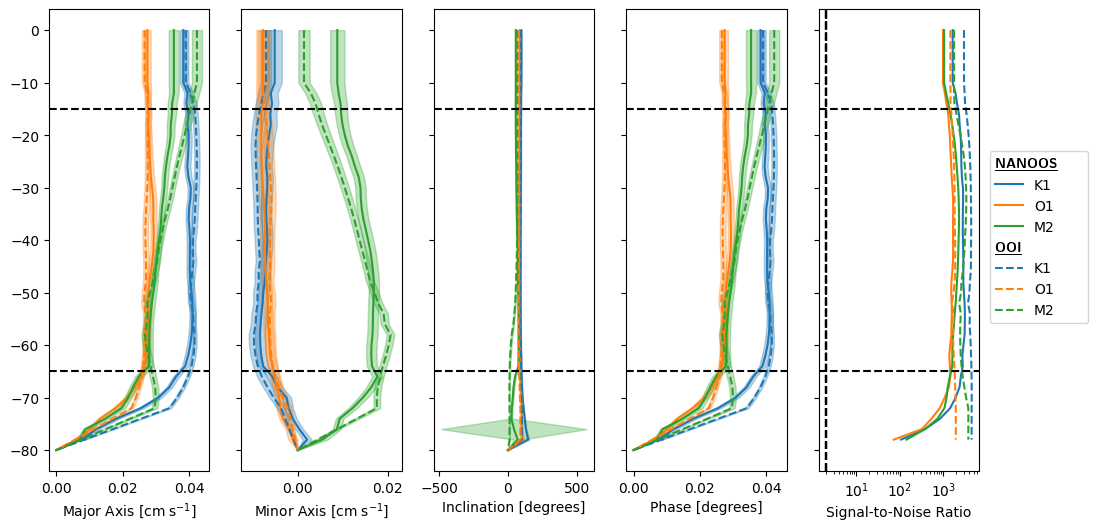

In [15]:
constituents = ["K1", "O1", "M2"]
colors = ["C0", "C1", "C2"]

fig, _ = plt.subplots(nrows=1, ncols=5, figsize=(12, 6), sharey=True)

# plot the tidal constituents for each deployment period on the same axes, using different line styles
fig = plot_tidal_constituents(tide_extrap_nanoos, fig, constituents, colors, linestyle="-")
fig = plot_tidal_constituents(tide_extrap_ooi, fig, constituents, colors, linestyle="--")

# fancy styling for the legend to add titles for each deployment period
axs = fig.axes
handles, labels = axs[0].get_legend_handles_labels()
# we add string type handles that will be converted to legend titles by the handler map in the legend call below
handles.insert(0, "NANOOS")  # ty:ignore[invalid-argument-type]
labels.insert(0, "")
handles.insert(4, "OOI")  # ty:ignore[invalid-argument-type]
labels.insert(4, "")
fig.legend(
    handles,
    labels,
    loc="center",
    bbox_to_anchor=(0.95, 0.5),
    handler_map={str: LegendTitle(text_props={"fontsize": 10}, width=55)},
)

# add some reference lines for the surface and bottom contamination
for ax in axs:
    ax.axhline(-15, color="k", linestyle="--")
    ax.axhline(-65, color="k", linestyle="--")

## Filtering

Next up is filtering the velocity time series. We use a 33 hr^-1 half-amplitude Lanczos window to filter the velocity. We apply this forwards and backwards to ensure no time shift in the filtered output. NaN values are filled with zeroes for the filtering and then masked out afterwards.

In [16]:
mask = velocity_extrap["u"].notnull() | velocity_extrap["v"].notnull()

num_taps = 101
cutoff_freq = 1 / 33  # cutoff frequency in cycles per hour (for a 33 hour low pass filter)
wts = xr.DataArray(sig.firwin(num_taps, cutoff_freq, window="lanczos", fs=1), dims=["time_win"])

# filter east/north velocities with zero phase shift filter along time axis
velocity_extrap["u_filt"] = (
    # apply filter once in the forward direction
    velocity_extrap["u"]
    .fillna(0)
    .rolling(time=num_taps, center=True)
    .construct(time="time_win")
    .dot(wts)
    # apply filter again in the backward direction to achieve zero phase shift
    .isel(time=slice(None, None, -1))
    .rolling(time=num_taps, center=True)
    .construct(time="time_win")
    .dot(wts)
)
velocity_extrap["v_filt"] = (
    # apply filter once in the forward direction
    velocity_extrap["v"]
    .fillna(0)
    .rolling(time=num_taps, center=True)
    .construct(time="time_win")
    .dot(wts)
    # apply filter again in the backward direction to achieve zero phase shift
    .isel(time=slice(None, None, -1))
    .rolling(time=num_taps, center=True)
    .construct(time="time_win")
    .dot(wts)
)
velocity_extrap["u_filt"] = velocity_extrap["u_filt"].where(mask)
velocity_extrap["v_filt"] = velocity_extrap["v_filt"].where(mask)

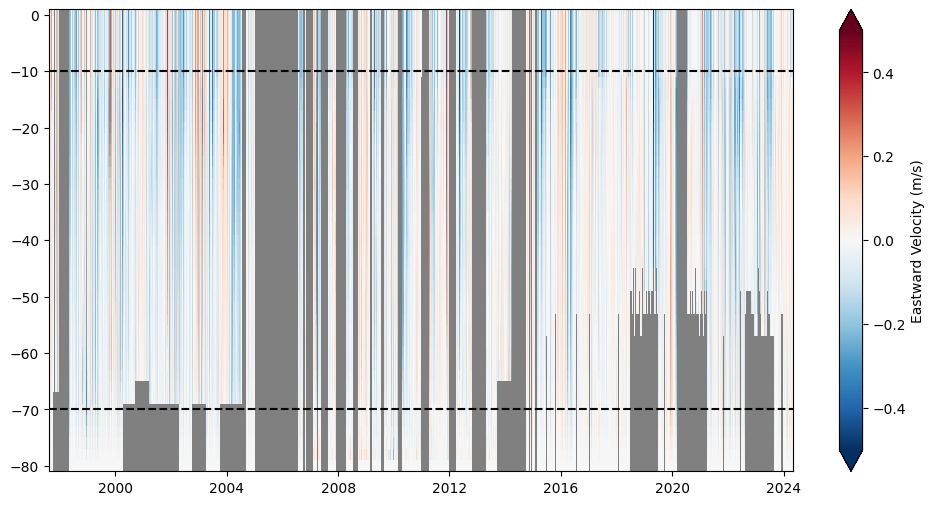

In [17]:
plot_velocity(velocity_extrap["u_filt"])

## Cross-shelf and along-shelf components

Our next goal is to calculate the cross-shelf and along-shelf components. This requires some care, since the along-shelf flows are so much larger than the cross-shelf flows.

A typical way is to begin by rotating the velocity vectors into the "principal axis of variation", that is, the axis along which the maximizes the variance of u/v. This is a useful way to identify the along-shelf direction while only needing information from the velocity data itself.

In [18]:
def princax(
    u: NDArray[floating],
    v: NDArray[floating],
) -> tuple[floating, floating, floating]:
    """Determine the principal axis of variance for the east and north velocities defined by u and v.

    Args:
        u (scalar or array): east velocity
        v (scalar or array): north velocity

    Returns:
        tuple of scalar: (theta, major, minor) - the angle of the principal axis CW from north,
            the variance along the major axis, and the variance along the minor axis

    """
    u = np.asarray(u)
    v = np.asarray(v)

    # only use finite values for covariance matrix
    ii = np.isfinite(u + v)
    uf = u[ii]
    vf = v[ii]

    # compute covariance matrix
    cov = np.cov(uf, vf)

    # calculate principal axis angle (ET, Equation 4.3.23b)
    # > 0 CCW from east axis, < 0 CW from east axis
    theta = 0.5 * np.rad2deg(np.arctan2(2.0 * cov[0, 1], (cov[0, 0] - cov[1, 1])))
    # switch to > 0 CW from north axis, < 0 CCW from north axis
    if theta >= 0:
        theta = 90 - theta
    elif theta < 0:
        theta = -(90 + theta)

    # calculate variance along major and minor axes (Equation 4.3.24)
    term1 = cov[0, 0] + cov[1, 1]
    term2 = ((cov[0, 0] - cov[1, 1]) ** 2 + 4 * (cov[0, 1] ** 2)) ** 0.5
    major = np.sqrt(0.5 * (term1 + term2))
    minor = np.sqrt(0.5 * (term1 - term2))

    return theta, major, minor


def rot(
    u: NDArray[floating],
    v: NDArray[floating],
    theta: float | floating,
) -> tuple[NDArray[floating], NDArray[floating]]:
    """Rotates a vector counter clockwise or a coordinate system clockwise.

    Designed to be used with theta output from princax(u, v).

    Args:
        u (scalar or array): x-component of vector
        v (scalar or array): y-component of vector
        theta (scalar): rotation angle (CCW > 0, CW < 0)

    Returns:
        tuple of scalar or array: (ur, vr) - x and y components of vector in rotated coordinate system

    """
    u = np.asarray(u)
    v = np.asarray(v)

    # rotate vector according to angle theta
    w = u + 1j * v
    ang = np.deg2rad(theta)
    wr = w * np.exp(1j * ang)
    ur = np.real(wr)
    vr = np.imag(wr)
    return ur, vr

In [19]:
# compute cross-shore and along-shore velocities based on principal axis of variance of depth mean velocities
theta, major, minor = princax(
    velocity_extrap["u_filt"].mean(dim="depth").values,
    velocity_extrap["v_filt"].mean(dim="depth").values,
)

# rotate into new coordinate system
cs_vel, as_vel = rot(velocity_extrap["u_filt"].values, velocity_extrap["v_filt"].values, theta)

# again, let's get things back into xarray world
# note that we're now calling these u_cs and u_as for cross-shore and along-shore components
velocity_extrap["u_cs"] = (velocity_extrap["u_filt"].dims, cs_vel)
velocity_extrap["u_as"] = (velocity_extrap["v_filt"].dims, as_vel)

Examining the original and rotated data:

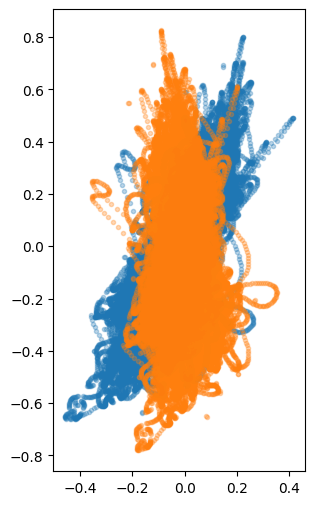

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(velocity_extrap["u_filt"].mean(dim="depth"), velocity_extrap["v_filt"].mean(dim="depth"), ".", alpha=0.3)
ax.plot(velocity_extrap["u_cs"].mean(dim="depth"), velocity_extrap["u_as"].mean(dim="depth"), ".", alpha=0.3)

ax.set_aspect("equal", adjustable="box")

McCabe et al. (2015) proposed a new way to calculate the cross-shelf flow that accounts for the time-varying, meandering nature of the along-shelf jet (rather than just rotating into principal axes in a time-mean sense).

Here, we find the angle of strongest depth-average flow *for every time step* and then find the normal flow $u_n$ to this strongest flow. Therefore, by definition, the cross-shelf flow will be normal to the strongest depth-averaged velocity. We then take this normal flow and project it back onto the cross-shelf direction in the coordinate system defined by the principal axis of variation to obtain a "projected" cross-shelf flow $u_{proj}$.

In [21]:
# compute cross-shore and along-shore velocities based on meandering along-shelf flow as in McCabe et al. (2015)
# first find the time-varying angle of the strongest depth mean flow
phi = xr.ufuncs.arctan2(
    velocity_extrap["u_as"].mean(dim="depth"),
    velocity_extrap["u_cs"].mean(dim="depth"),
)


# now compute the velocity component normal to that flow (Eqn. 3 in McCabe et al. 2015)
u_n = -velocity_extrap["u_cs"] * xr.ufuncs.sin(phi) + velocity_extrap["u_as"] * xr.ufuncs.cos(phi)

velocity_extrap["u_proj"] = u_n * -xr.ufuncs.sin(phi)

Now let's take a quick look at each step in this process, as an example for the first time step. We're going to see how the depth mean velocity is rotated in each of these steps in the plot below.

In [22]:
def draw_arc(
    ax: plt.Axes,
    center: tuple[float, float],
    radius: float,
    theta1: float,
    theta2: float,
    **kwargs: Any,  # noqa: ANN401
) -> Arc:
    """Draw an arc on a matplotlib axis.

    Args:
        ax (plt.Axes): The axis to draw the arc on.
        center (tuple[float, float]): The (x, y) coordinates of the center of the arc.
        radius (float): The radius of the arc.
        theta1 (float): The starting angle of the arc in degrees.
        theta2 (float): The ending angle of the arc in degrees.
        **kwargs (Any): Additional keyword arguments to pass to the Arc patch.

    Returns:
        Arc: The Arc patch that was added to the axis.

    """
    arc = Arc(center, 2 * radius, 2 * radius, angle=0, theta1=theta1, theta2=theta2, **kwargs)
    ax.add_patch(arc)
    return arc

First, the rotation due to the principal axis. This is shown by the blue angle below. Next, we identify the angle between the depth mean velocity (the upstream direction) and the +x axis, shown in orange below.

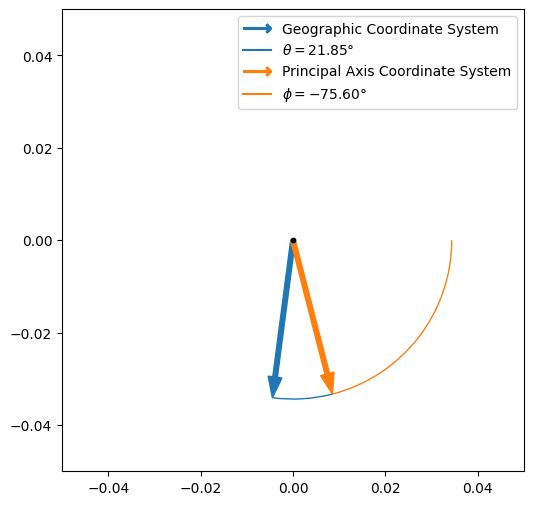

In [23]:
idx = 20000

fig, ax = plt.subplots(figsize=(6, 6))

ax.arrow(
    0,
    0,
    velocity_extrap["u_filt"].mean(dim="depth").isel(time=idx).item(),
    velocity_extrap["v_filt"].mean(dim="depth").isel(time=idx).item(),
    length_includes_head=True,
    color="C0",
)
ax.arrow(
    0,
    0,
    velocity_extrap["u_cs"].mean(dim="depth").isel(time=idx).item(),
    velocity_extrap["u_as"].mean(dim="depth").isel(time=idx).item(),
    length_includes_head=True,
    color="C1",
)

center = (0, 0)
radius = float(
    np.linalg.norm(
        [
            velocity_extrap["u_cs"].mean(dim="depth").isel(time=idx).item(),
            velocity_extrap["u_as"].mean(dim="depth").isel(time=idx).item(),
        ],
    ),
)
theta1 = np.rad2deg(
    np.arctan2(
        velocity_extrap["v_filt"].mean(dim="depth").isel(time=idx).item(),
        velocity_extrap["u_filt"].mean(dim="depth").isel(time=idx).item(),
    ),
)
theta2 = np.rad2deg(phi.isel(time=idx))


draw_arc(ax, center, radius, theta1, theta2, color="C0", label=f"$\\theta=\\mathsf{{{theta:.2f}}}\\degree$")
draw_arc(ax, center, radius, theta2, 0, color="C1", label=f"$\\phi=\\mathsf{{{theta2:.2f}}}\\degree$")

# draw origin dot
ax.scatter([0], [0], s=10, c="k")

# custom legend stuff
labels = [
    "Geographic Coordinate System",
    f"$\\theta=\\mathsf{{{theta:.2f}}}\\degree$",
    "Principal Axis Coordinate System",
    f"$\\phi=\\mathsf{{{theta2:.2f}}}\\degree$",
]
handles = [
    Line2D([0], [0], color="C0", marker="$\\longrightarrow$", markersize=20, linestyle="none"),
    Line2D([0], [0], color="C0"),
    Line2D([0], [0], color="C1", marker="$\\longrightarrow$", markersize=20, linestyle="none"),
    Line2D([0], [0], color="C1"),
]
ax.legend(handles, labels)

ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-0.05, 0.05)
ax.set_aspect("equal", adjustable="box")

The next step of the process is to rotate the principal axis coordinate system at each time $t$ such that the depth mean velocity $\bar{\vec{u}}(t)$ points only in the +x direction. This involves a clockwise rotation, such that when $\phi(t)>0$ (the flow is more northward) the vector rotates clockwise, and when $\phi(t)<0$ (the flow is more southward) the vector rotates counterclockwise.

This is done by using the clockwise rotation matrix:

\begin{equation*}
    \begin{pmatrix}
        u_s \\
        u_n
    \end{pmatrix}
    =
    \begin{pmatrix}
        \cos(\phi) & \sin(\phi) \\
        -\sin(\phi) & \cos(\phi)
    \end{pmatrix}
    \begin{pmatrix}
        u_{cs} \\
        u_{as}
    \end{pmatrix}
\end{equation*}

We can verify this works first for the depth mean velocity, which should result in only a component for $u_s$ and no component for $u_n$.

In [24]:
# u_s
(
    velocity_extrap["u_cs"].isel(time=idx).mean(dim="depth").item() * np.cos(phi.isel(time=idx).item())
    + velocity_extrap["u_as"].isel(time=idx).mean(dim="depth").item() * np.sin(phi.isel(time=idx).item())
)

np.float64(0.03436394226117635)

In [25]:
# u_n = 0, to within machine precision
(
    -velocity_extrap["u_cs"].isel(time=idx).mean(dim="depth").item() * np.sin(phi.isel(time=idx).item())
    + velocity_extrap["u_as"].isel(time=idx).mean(dim="depth").item() * np.cos(phi.isel(time=idx).item())
)

np.float64(3.469446951953614e-18)

This property (that the normal component of the depth mean flow is forced to be zero) is what preserves the dynamically preferrable property of net mass balance in the cross-shelf direction.

We now apply this rotation to the full depth-varying velocity $u_{cs}(z, t)$ to obtain $u_n(z,t)$. Two rotated vectors, one from 20 m depth and one from 40 m depth, are shown below. These vectors illustrate the extrapretation of $u_n(z,t)$: when $u_n(z,t)>0$, there is net onshore flow (as is the case for 20 m depth here) and when $u_n(z,t)<0$, there is net offshore flow (as is the case for 40 m depth here).

(-0.05, 0.05)

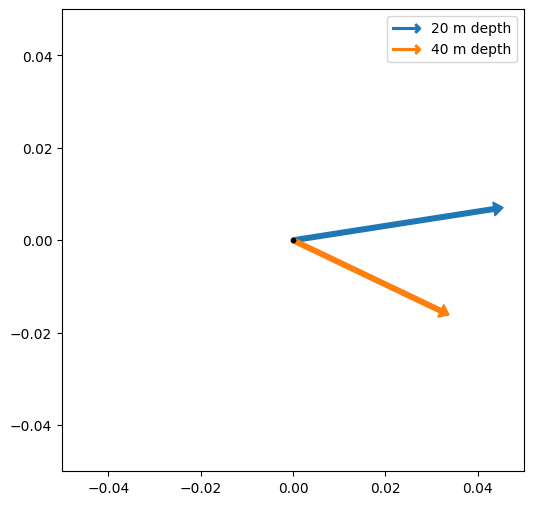

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.arrow(
    0,
    0,
    (
        velocity_extrap["u_cs"].isel(time=idx).sel(depth=20) * np.cos(phi.isel(time=idx))
        + velocity_extrap["u_as"].isel(time=idx).sel(depth=20) * np.sin(phi.isel(time=idx))
    ).item(),
    (
        -velocity_extrap["u_cs"].isel(time=idx).sel(depth=20) * np.sin(phi.isel(time=idx))
        + velocity_extrap["u_as"].isel(time=idx).sel(depth=20) * np.cos(phi.isel(time=idx))
    ).item(),
    length_includes_head=True,
    color="C0",
    head_width=0.003,
    head_length=0.002,
)
ax.arrow(
    0,
    0,
    (
        velocity_extrap["u_cs"].isel(time=idx).sel(depth=40) * np.cos(phi.isel(time=idx))
        + velocity_extrap["u_as"].isel(time=idx).sel(depth=40) * np.sin(phi.isel(time=idx))
    ).item(),
    (
        -velocity_extrap["u_cs"].isel(time=idx).sel(depth=40) * np.sin(phi.isel(time=idx))
        + velocity_extrap["u_as"].isel(time=idx).sel(depth=40) * np.cos(phi.isel(time=idx))
    ).item(),
    length_includes_head=True,
    color="C1",
    head_width=0.003,
    head_length=0.002,
)
# draw origin dot
ax.scatter([0], [0], s=10, c="k")

# custom legend stuff
labels = [
    "20 m depth",
    "40 m depth",
]
handles = [
    Line2D([0], [0], color="C0", marker="$\\longrightarrow$", markersize=20, linestyle="none"),
    Line2D([0], [0], color="C1", marker="$\\longrightarrow$", markersize=20, linestyle="none"),
]
ax.legend(handles, labels)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-0.05, 0.05)

We can now rotate *only* the normal component of the vector back into the principal axis frame using the typical counterclockwise rotation matrix:


\begin{equation*}
    \begin{pmatrix}
        u_p \\
        u_p
    \end{pmatrix}
    =
    \begin{pmatrix}
        \cos(\phi) & -\sin(\phi) \\
        \sin(\phi) & \cos(\phi)
    \end{pmatrix}
    \begin{pmatrix}
        0 \\
        u_n
    \end{pmatrix}
\end{equation*}

where we have suggestively chosen $u_p$ as the x-component of the resulting vector. Indeed, the x-component of this resulting vector $u_p$ is exactly the $u_{proj}$ we are after!

We can check our work by calculating the angle difference between the vector $(u_p, v_p)$ and the depth mean flow $(\bar{u}, \bar{v})$, which should always result in orthogonal vectors ($\theta=\{ -270, -90, 90, 270 \}$, depending on the signs of each).

In [27]:
# round to 10 decimal places and take the result mod 90
delta_theta = (
    np.round(
        np.angle(u_n * -np.sin(phi) + 1j * u_n * np.cos(phi), deg=True)
        - np.angle(np.nanmean(cs_vel, axis=0) + 1j * np.nanmean(as_vel, axis=0), deg=True),
        10,
    )
    % 90
)

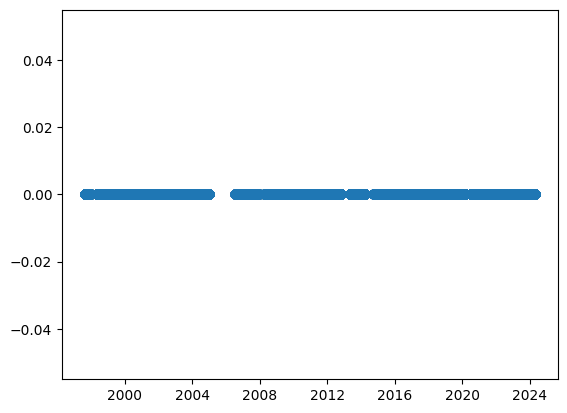

In [28]:
# indeed, always zero!
plt.plot(velocity["time"], delta_theta[10], "o")

It's now straightforward to see that the x-component of the resulting vector is given by $u_{proj} \equiv u_p = -u_n \sin(\phi)$.

All in all, we can compare the original vector from 10 m depth, the depth mean flow direction, and the two vectors $u_n$ and $u_{proj}$ in the following figure:

(-0.05, 0.05)

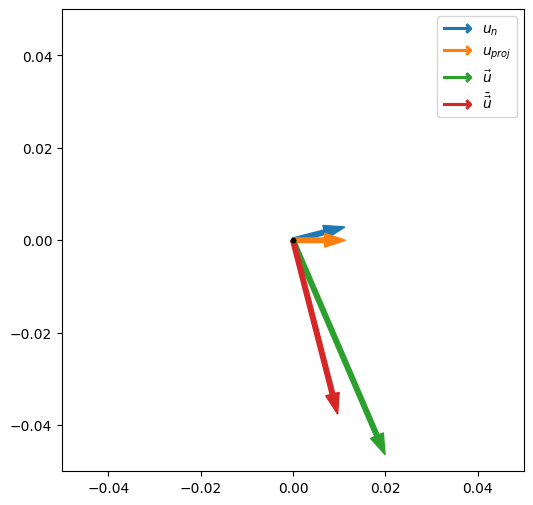

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))


ax.arrow(
    0,
    0,
    u_n[10, idx] * -np.sin(phi[idx]),
    u_n[10, idx] * np.cos(phi[idx]),
    color="C0",
)
ax.arrow(
    0,
    0,
    u_n[10, idx] * -np.sin(phi[idx]),
    0,
    color="C1",
)
ax.arrow(
    0,
    0,
    cs_vel[10, idx],
    as_vel[10, idx],
    color="C2",
)
ax.arrow(
    0,
    0,
    np.nanmean(cs_vel, axis=0)[idx],
    np.nanmean(as_vel, axis=0)[idx],
    color="C3",
)
ax.scatter([0], [0], s=10, c="k")


# custom legend stuff
labels = [
    "$u_{n}$",
    "$u_{proj}$",
    "$\\vec{u}$",
    "$\\bar{\\vec{u}}$",
]
handles = [
    Line2D([0], [0], color="C0", marker="$\\longrightarrow$", markersize=20, linestyle="none"),
    Line2D([0], [0], color="C1", marker="$\\longrightarrow$", markersize=20, linestyle="none"),
    Line2D([0], [0], color="C2", marker="$\\longrightarrow$", markersize=20, linestyle="none"),
    Line2D([0], [0], color="C3", marker="$\\longrightarrow$", markersize=20, linestyle="none"),
]
ax.legend(handles, labels)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-0.05, 0.05)

Finally, we calculate the more "traditional" depth-varying part of the cross-shelf velocity, $\tilde{u}_{cs}$. We're now replacing the variable $u_{cs}$ in the dataset with $\tilde{u}_{cs}$, to save the cumbersome writing of `tilde_u_cs` anytime we want to use this velocity!

In [30]:
velocity_extrap["u_cs"] -= velocity_extrap["u_cs"].mean(dim="time")

## Wrapping things up

Finally, let's put everything back into an `xr.Dataset` (thankfully!) and then take a look at both $u_{cs}$ and $u_{proj}$.

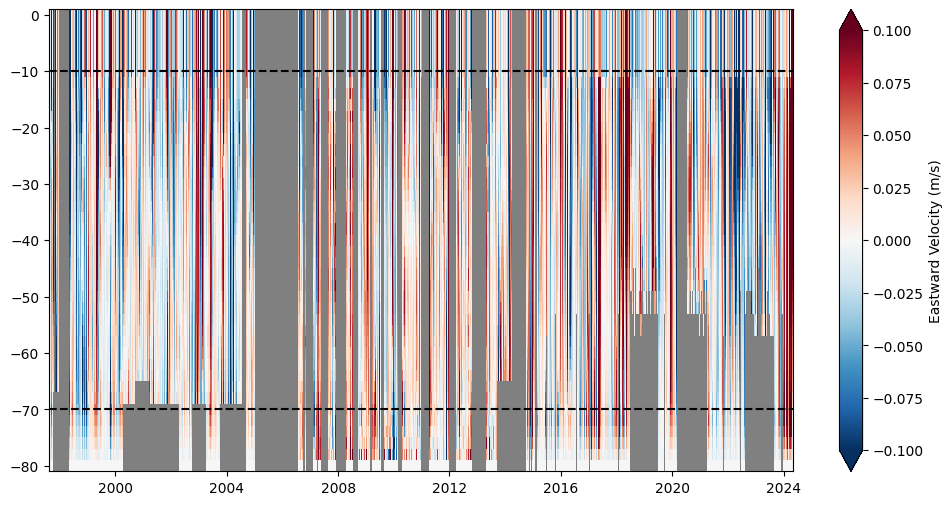

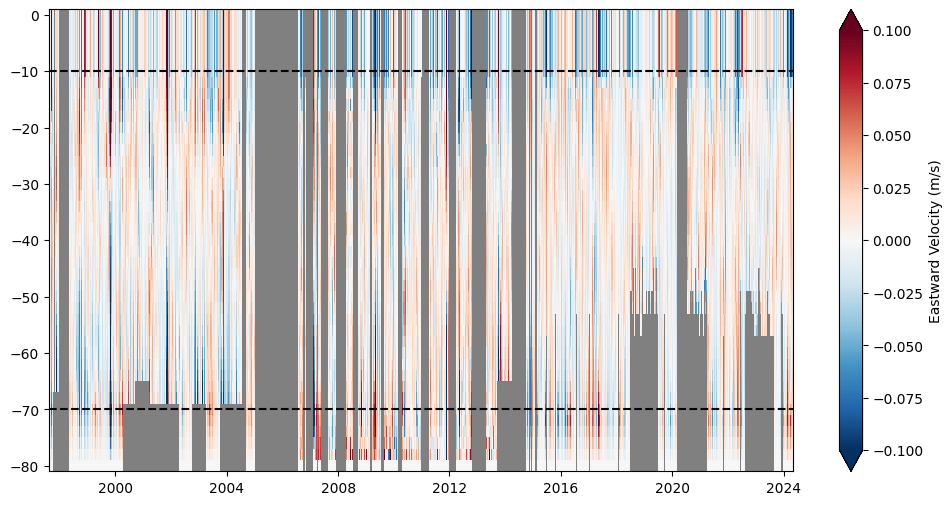

In [31]:
plot_velocity(velocity_extrap["u_cs"], vmin=-0.1, vmax=0.1)
plot_velocity(velocity_extrap["u_proj"], vmin=-0.1, vmax=0.1)

We can see here that $u_{proj}$ tends to have smaller magnitudes, which correspond to times when the meandering of the along-shelf jet is aliasing into the cross-shelf velocity $u_{cs}$. $u_{proj}$ is the velocity variable ultimately chosen to be used in the associated manuscript. However, the choice between $u_{cs}$ and $u_{proj}$ does not effect any of the results herein.